

# <center><b><b></center>

# <center><b>Loan Default Risk Analysis<b></center>


### 📌 **Problem Statement**
 Horizon Financial Group has experienced a significant increase in loan defaults across its personal lending portfolio during 2024–2025. With over 600 loans issued, the current default rate stands at approximately 25%, which is more than double the company’s target default rate of 12%. This rising trend poses a substantial risk to profitability, portfolio stability, and overall risk management practices. The objective of this analysis is to identify the key factors contributing to loan defaults by examining borrower characteristics (such as demographics, income, employment status, and credit score) alongside loan attributes (including loan amount, tenure, and interest rate). By leveraging these datasets, the analysis aims to uncover patterns, correlations, and high-risk segments within the loan portfolio. The insights derived from this study will support the VP of Risk in refining the company’s credit scoring model, improving underwriting criteria, and establishing more effective loan approval thresholds to reduce future default rates and enhance portfolio performance.


#### 📂**Import libraries**

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

#### 📁**Load Datasets**

In [ ]:
!git clone https://github.com/muqadamfarheen/Loan-default-risk-analysis-.git

Cloning into 'Loan-default-risk-analysis-'...
remote: Enumerating objects: 7, done.
remote: Counting objects: 100% (7/7), done.
remote: Compressing objects: 100% (5/5), done.
remote: Total 7 (delta 0), reused 0 (delta 0), pack-reused 0 (from 0)
Receiving objects: 100% (7/7), 24.32 KiB | 2.03 MiB/s, done.


In [ ]:
borrower = pd.read_csv("Loan-default-risk-analysis-/borrower_profiles.csv")

In [ ]:
borrower.head()

,borrower_id,age,state,education_level,employment_status,years_employed,annual_income,credit_score,home_ownership,dependents,existing_monthly_debt
0,BRW-0001,62,CT,High School,Self-Employed,6,31020,596,Rent,1,892
1,BRW-0002,24,CO,High School,Full-Time,4,40188,543,Own,2,869
2,BRW-0003,50,NC,Bachelor,Contract,22,41014,611,Mortgage,0,1806
3,BRW-0004,43,TX,High School,Full-Time,19,35036,701,Mortgage,2,928
4,BRW-0005,46,NY,High School,Full-Time,18,44528,715,Own,0,608


In [ ]:
loan = pd.read_csv("Loan-default-risk-analysis-/loan_applications.csv")

In [ ]:
loan.head()

,loan_id,borrower_id,application_date,loan_purpose,loan_amount,term_months,interest_rate,monthly_payment,dti_ratio,loan_status,days_delinquent,defaulted
0,LN-00001,BRW-0001,2024-01-08,Vacation,16100.0,36,13.05,542.86,55.5,Paid Off,0,0
1,LN-00002,BRW-0001,2024-08-13,Major Purchase,5600.0,48,14.21,153.62,40.4,Default,138,1
2,LN-00003,BRW-0002,2025-06-28,Moving,44700.0,36,12.37,1492.59,70.5,Paid Off,0,0
3,LN-00004,BRW-0003,2025-05-18,Auto Loan,9200.0,48,11.18,238.58,59.8,Default,34,1
4,LN-00005,BRW-0004,2025-03-24,Moving,11200.0,36,9.66,359.61,44.1,Current,0,0


#### 🔍 **Data Overview**

In [ ]:
borrower.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 11 columns):
 #   Column                 Non-Null Count  Dtype 
---  ------                 --------------  ----- 
 0   borrower_id            500 non-null    object
 1   age                    500 non-null    int64 
 2   state                  500 non-null    object
 3   education_level        500 non-null    object
 4   employment_status      500 non-null    object
 5   years_employed         500 non-null    int64 
 6   annual_income          500 non-null    int64 
 7   credit_score           500 non-null    int64 
 8   home_ownership         500 non-null    object
 9   dependents             500 non-null    int64 
 10  existing_monthly_debt  500 non-null    int64 
dtypes: int64(6), object(5)
memory usage: 43.1+ KB


In [ ]:
loan.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 601 entries, 0 to 600
Data columns (total 12 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   loan_id           601 non-null    object 
 1   borrower_id       601 non-null    object 
 2   application_date  601 non-null    object 
 3   loan_purpose      601 non-null    object 
 4   loan_amount       601 non-null    float64
 5   term_months       601 non-null    int64  
 6   interest_rate     601 non-null    float64
 7   monthly_payment   601 non-null    float64
 8   dti_ratio         601 non-null    float64
 9   loan_status       601 non-null    object 
 10  days_delinquent   601 non-null    int64  
 11  defaulted         601 non-null    int64  
dtypes: float64(4), int64(3), object(5)
memory usage: 56.5+ KB


In [ ]:
borrower.shape

(500, 11)

#### 🔗 **Data Merging (Join Datasets)**

In [ ]:
merged_df = pd.merge(borrower, loan, on="borrower_id", how="left")

In [ ]:
merged_df.shape

(601, 22)

#### 🔍 **Data Overview**

In [ ]:
merged_df.head()

,borrower_id,age,state,education_level,employment_status,years_employed,annual_income,credit_score,home_ownership,dependents,...,application_date,loan_purpose,loan_amount,term_months,interest_rate,monthly_payment,dti_ratio,loan_status,days_delinquent,defaulted
0,BRW-0001,62,CT,High School,Self-Employed,6,31020,596,Rent,1,...,2024-01-08,Vacation,16100.0,36,13.05,542.86,55.5,Paid Off,0,0
1,BRW-0001,62,CT,High School,Self-Employed,6,31020,596,Rent,1,...,2024-08-13,Major Purchase,5600.0,48,14.21,153.62,40.4,Default,138,1
2,BRW-0002,24,CO,High School,Full-Time,4,40188,543,Own,2,...,2025-06-28,Moving,44700.0,36,12.37,1492.59,70.5,Paid Off,0,0
3,BRW-0003,50,NC,Bachelor,Contract,22,41014,611,Mortgage,0,...,2025-05-18,Auto Loan,9200.0,48,11.18,238.58,59.8,Default,34,1
4,BRW-0004,43,TX,High School,Full-Time,19,35036,701,Mortgage,2,...,2025-03-24,Moving,11200.0,36,9.66,359.61,44.1,Current,0,0


In [ ]:
merged_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 601 entries, 0 to 600
Data columns (total 22 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   borrower_id            601 non-null    object 
 1   age                    601 non-null    int64  
 2   state                  601 non-null    object 
 3   education_level        601 non-null    object 
 4   employment_status      601 non-null    object 
 5   years_employed         601 non-null    int64  
 6   annual_income          601 non-null    int64  
 7   credit_score           601 non-null    int64  
 8   home_ownership         601 non-null    object 
 9   dependents             601 non-null    int64  
 10  existing_monthly_debt  601 non-null    int64  
 11  loan_id                601 non-null    object 
 12  application_date       601 non-null    object 
 13  loan_purpose           601 non-null    object 
 14  loan_amount            601 non-null    float64
 15  term_m

In [ ]:
merged_df.drop_duplicates(inplace=True)

In [ ]:
merged_df.shape
merged_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 601 entries, 0 to 600
Data columns (total 25 columns):
 #   Column                 Non-Null Count  Dtype   
---  ------                 --------------  -----   
 0   borrower_id            601 non-null    object  
 1   age                    601 non-null    int64   
 2   state                  601 non-null    object  
 3   education_level        601 non-null    object  
 4   employment_status      601 non-null    object  
 5   years_employed         601 non-null    int64   
 6   annual_income          601 non-null    int64   
 7   credit_score           601 non-null    int64   
 8   home_ownership         601 non-null    object  
 9   dependents             601 non-null    int64   
 10  existing_monthly_debt  601 non-null    int64   
 11  loan_id                601 non-null    object  
 12  application_date       601 non-null    object  
 13  loan_purpose           601 non-null    object  
 14  loan_amount            601 non-null    flo

#### **Default Rate**

In [ ]:
default_rate = merged_df["defaulted"].mean()
print(default_rate)

0.24292845257903495


#### **24% Default Rate**

#### **Feature Engineering**

In [ ]:
bins = [520,600,650,700,750,850]

labels = [
"520-599",
"600-649",
"650-699",
"700-749",
"750+"
]

merged_df["credit_bucket"] = pd.cut(merged_df["credit_score"],
                             bins=bins,
                             labels=labels)

In [ ]:
credit_default_rate = merged_df.groupby("credit_bucket")["defaulted"].mean()

/tmp/ipykernel_6454/2647324600.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  credit_default_rate = merged_df.groupby("credit_bucket")["defaulted"].mean()


In [ ]:
credit_default_rate

,defaulted
credit_bucket,
520-599,0.491525
600-649,0.282609
650-699,0.282051
700-749,0.152941
750+,0.118421


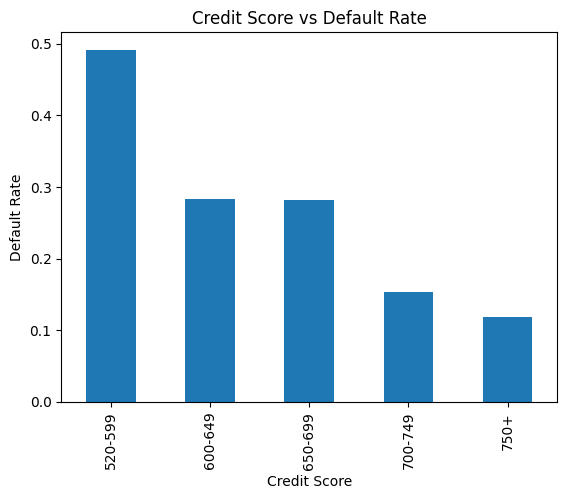

In [ ]:
credit_default_rate.plot(kind="bar")
plt.title("Credit Score vs Default Rate")
plt.xlabel("Credit Score")
plt.ylabel("Default Rate")
plt.show()

- borrowers below 600 credit score are showing high default rate

In [ ]:
dti_bins = [0,20,30,40,50,70,100]

dti_labels = [
"0-20",
"20-30",
"30-40",
"40-50",
"50-70",
"70+"
]

merged_df["dti_bucket"] = pd.cut(merged_df["dti_ratio"],
                                 bins=dti_bins,
                                 labels=dti_labels)

In [ ]:
dti_default_rate = merged_df.groupby("dti_bucket")["defaulted"].mean()
dti_default_rate

/tmp/ipykernel_6454/2336215054.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  dti_default_rate = merged_df.groupby("dti_bucket")["defaulted"].mean()


,defaulted
dti_bucket,
0-20,0.166667
20-30,0.128205
30-40,0.117117
40-50,0.234043
50-70,0.325714
70+,0.383562


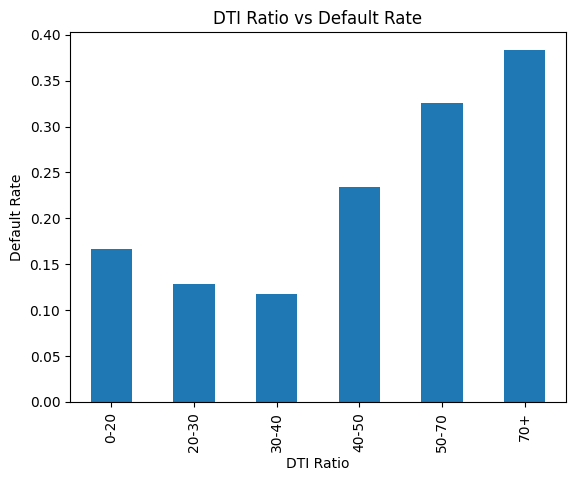

In [ ]:
dti_default_rate.plot(kind="bar")
plt.title("DTI Ratio vs Default Rate")
plt.xlabel("DTI Ratio")
plt.ylabel("Default Rate")
plt.show()

- borrowers with dti ratio above 40% have high default rate

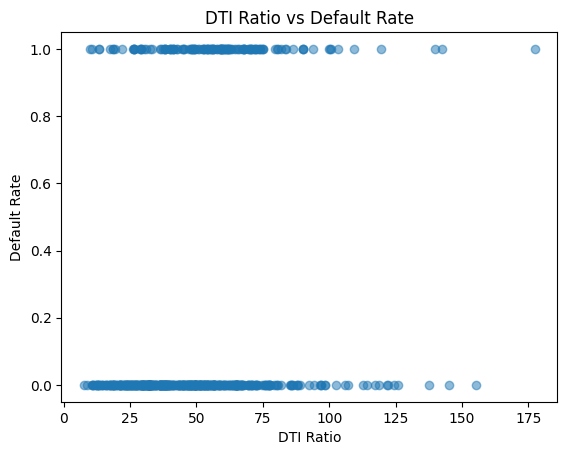

In [ ]:
plt.scatter(merged_df["dti_ratio"], merged_df["defaulted"], alpha=0.5)
plt.title("DTI Ratio vs Default Rate")
plt.xlabel("DTI Ratio")
plt.ylabel("Default Rate")
plt.show()

- Raw scatter didn’t provide insight due to binary target. I aggregated default rate across DTI buckets to identify risk patterns, which is more meaningful for decision-making.

In [ ]:
purpose_default_rate = merged_df.groupby("loan_purpose")["defaulted"].mean()
purpose_default_rate


,defaulted
loan_purpose,
Auto Loan,0.271186
Business Loan,0.241379
Debt Consolidation,0.215686
Education,0.226415
Home Improvement,0.285714
Major Purchase,0.220588
Medical Expenses,0.205882
Moving,0.214286
Vacation,0.225806


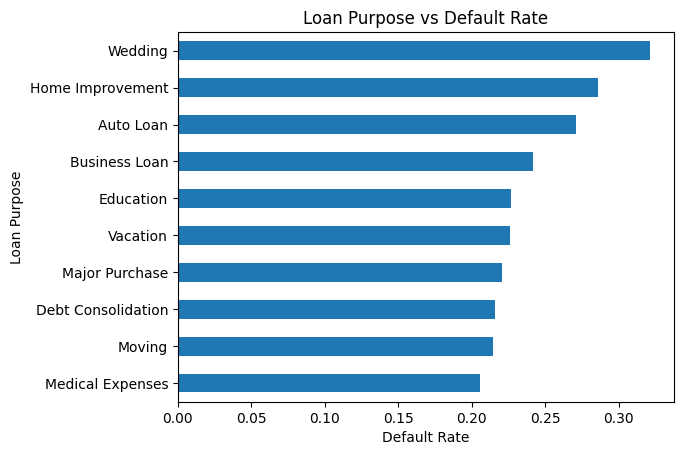

In [ ]:
purpose_default_rate.sort_values().plot(kind="barh")
plt.title("Loan Purpose vs Default Rate")
plt.xlabel("Default Rate")
plt.ylabel("Loan Purpose")
plt.show()

- wedding , home improvement and auto loans are the top 3 categories with high default rate

In [ ]:
merged_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 601 entries, 0 to 600
Data columns (total 24 columns):
 #   Column                 Non-Null Count  Dtype   
---  ------                 --------------  -----   
 0   borrower_id            601 non-null    object  
 1   age                    601 non-null    int64   
 2   state                  601 non-null    object  
 3   education_level        601 non-null    object  
 4   employment_status      601 non-null    object  
 5   years_employed         601 non-null    int64   
 6   annual_income          601 non-null    int64   
 7   credit_score           601 non-null    int64   
 8   home_ownership         601 non-null    object  
 9   dependents             601 non-null    int64   
 10  existing_monthly_debt  601 non-null    int64   
 11  loan_id                601 non-null    object  
 12  application_date       601 non-null    object  
 13  loan_purpose           601 non-null    object  
 14  loan_amount            601 non-null    flo

In [ ]:
employment_status_default_rate = merged_df.groupby("employment_status")["defaulted"].mean()
employment_status_default_rate

,defaulted
employment_status,
Contract,0.227273
Full-Time,0.239344
Part-Time,0.276923
Retired,0.233333
Self-Employed,0.247619


<function matplotlib.pyplot.show(close=None, block=None)>

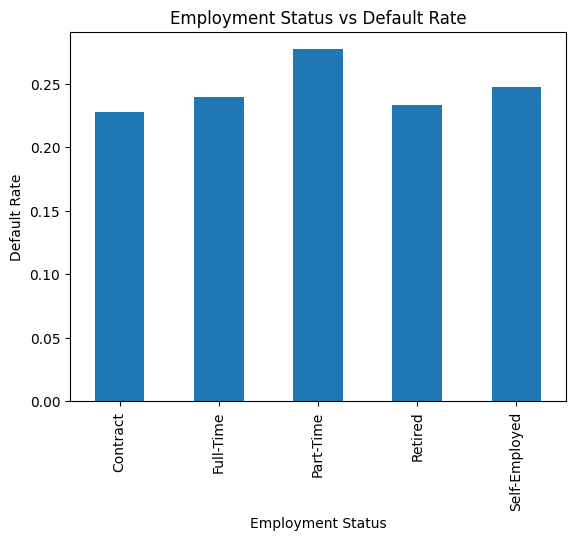

In [ ]:
employment_status_default_rate.plot(kind="bar")
plt.title("Employment Status vs Default Rate")
plt.xlabel("Employment Status")
plt.ylabel("Default Rate")
plt.show

- Employment status is poor indicator for defautl rate hence passing it

In [ ]:
merged_df.groupby("defaulted")["loan_amount"].mean()

,loan_amount
defaulted,
0,22012.747253
1,22570.547945


<function matplotlib.pyplot.show(close=None, block=None)>

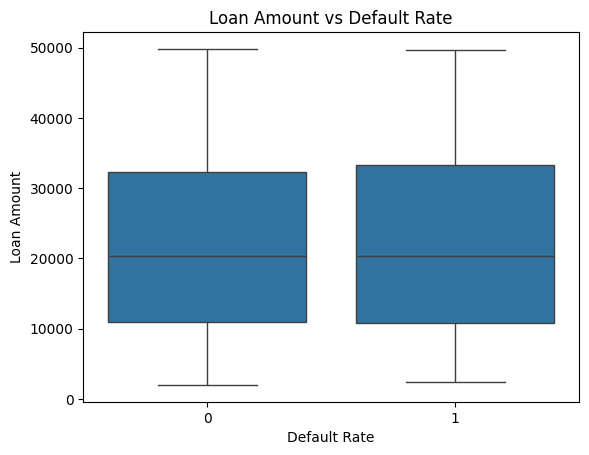

In [ ]:
sns.boxplot(x="defaulted", y="loan_amount", data=merged_df)
plt.title("Loan Amount vs Default Rate")
plt.xlabel("Default Rate")
plt.ylabel("Loan Amount")
plt.show

- high loan amount is showing slightly high default rate but not strong like credit score

In [ ]:
merged_df['short_employment'] = merged_df['years_employed'] < 2

In [ ]:
merged_df['short_employment'].value_counts()

,count
short_employment,
False,517
True,84


In [ ]:
employment_default = merged_df.groupby('short_employment')['defaulted'].mean()
employment_default

,defaulted
short_employment,
False,0.226306
True,0.345238


<function matplotlib.pyplot.show(close=None, block=None)>

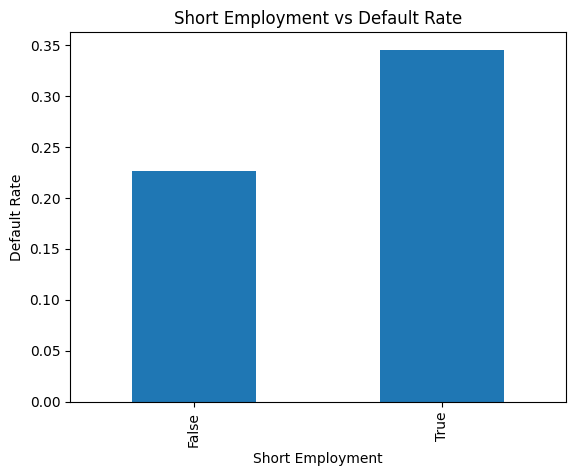

In [ ]:
employment_default.plot(kind='bar')
plt.title('Short Employment vs Default Rate')
plt.xlabel('Short Employment')
plt.ylabel('Default Rate')
plt.show

- people with work experience less than 2 years have high default rate

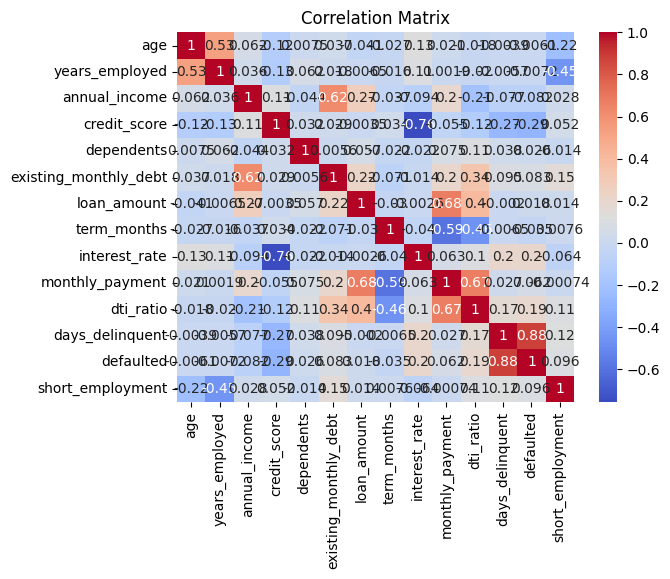

In [ ]:
corr = merged_df.corr(numeric_only = True)
sns.heatmap(corr, annot=True, cmap='coolwarm')
plt.title('Correlation Matrix')
plt.show()